In [147]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import StrMethodFormatter

df_inventory = pd.read_csv("../Data/Cleaned Data/df_inventory.csv")
df_inventory.head()

,Shim ID,FHFC Key,HUD REMS,Public Housing Development #,Florida DOR Parcel,Development Name,Street Address,City,Zip Code,County,...,"% of Households with at least one child age 0-17, 2018-2022, Tract","% of Households with at least one child age 0-17, 2018-2022, County","% of Households with at least one person age 65 or older, 2018-2022, Tract","% of Households with at least one person age 65 or older, 2018-2022, County",Total Living Area,Number of Buildings,REAC Score (HUD only),REAC Inspection Date,Construction Type (FHFC Only)',In unincorporated area
0,1213,-,800003897,-,3926002000,Alachua Apts,13605 NW County Road 235,Alachua,32615,Alachua,...,19.46,22.34,32.83,26.18,56979,15,96,2025-05-20,not avail.,NaN
1,112,-,-,-,3563000000,Alachua Villas,14000 NW 154TH AVE,Alachua,32615,Alachua,...,34.30,22.34,38.12,26.18,26660,9,-,-,not avail.,NaN
2,7872,3308,-,-,3214035000,Arbours at Merrillwood I,13207 NW 153rd Place,Alachua,32615,Alachua,...,39.30,22.34,25.72,26.18,NaN,NaN,-,-,not avail.,NaN
3,7999,3454,-,-,3926002000,Sherwood Oaks,13605 NW County Road 235,Alachua,32615,Alachua,...,19.46,22.34,32.83,26.18,NaN,NaN,-,-,Construction Category Not Found,NaN
4,1356,-,800004435,-,3926020000,Sherwood Oaks Apartments,13400 NW 140th St,Alachua,32615,Alachua,...,19.46,22.34,32.83,26.18,48982,11,83b,2018-11-19,not avail.,NaN


In [148]:
#Cleaned Data
df_inventory = df_inventory.replace({'-': 0, 'x': 1, 'not avail.': 0})
df_inventory.head()

,Shim ID,FHFC Key,HUD REMS,Public Housing Development #,Florida DOR Parcel,Development Name,Street Address,City,Zip Code,County,...,"% of Households with at least one child age 0-17, 2018-2022, Tract","% of Households with at least one child age 0-17, 2018-2022, County","% of Households with at least one person age 65 or older, 2018-2022, Tract","% of Households with at least one person age 65 or older, 2018-2022, County",Total Living Area,Number of Buildings,REAC Score (HUD only),REAC Inspection Date,Construction Type (FHFC Only)',In unincorporated area
0,1213,0,800003897,0,3926002000,Alachua Apts,13605 NW County Road 235,Alachua,32615,Alachua,...,19.46,22.34,32.83,26.18,56979,15,96,2025-05-20,0,NaN
1,112,0,0,0,3563000000,Alachua Villas,14000 NW 154TH AVE,Alachua,32615,Alachua,...,34.30,22.34,38.12,26.18,26660,9,0,0,0,NaN
2,7872,3308,0,0,3214035000,Arbours at Merrillwood I,13207 NW 153rd Place,Alachua,32615,Alachua,...,39.30,22.34,25.72,26.18,NaN,NaN,0,0,0,NaN
3,7999,3454,0,0,3926002000,Sherwood Oaks,13605 NW County Road 235,Alachua,32615,Alachua,...,19.46,22.34,32.83,26.18,NaN,NaN,0,0,Construction Category Not Found,NaN
4,1356,0,800004435,0,3926020000,Sherwood Oaks Apartments,13400 NW 140th St,Alachua,32615,Alachua,...,19.46,22.34,32.83,26.18,48982,11,83b,2018-11-19,0,NaN


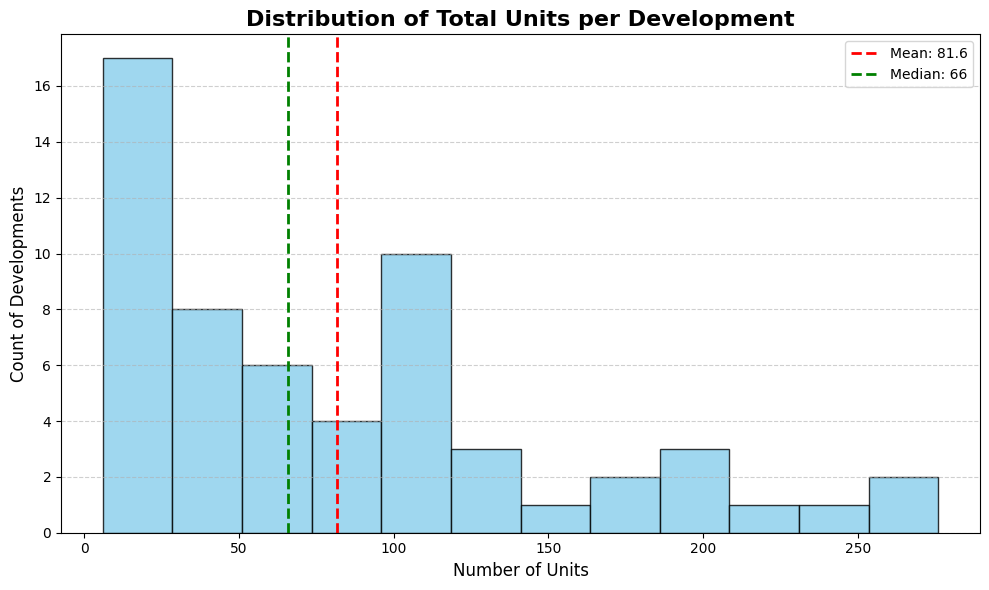

In [149]:
# Histogram of Total Units
# 2. Convert to numeric (essential for plotting)
df_inventory['Total Units'] = pd.to_numeric(df_inventory['Total Units'], errors='coerce')

# 3. Create a Polished Histogram
plt.figure(figsize=(10, 6))

# Use 12 bins for a dataset of this size (~60 entries)
# edgecolor='black' helps distinguish individual bars
plt.hist(df_inventory['Total Units'].dropna(), bins=12, color='skyblue', edgecolor='black', alpha=0.8)

# 4. Add Statistical Lines (Mean and Median)
mean_val = df_inventory['Total Units'].mean()
median_val = df_inventory['Total Units'].median()

plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.1f}')
plt.axvline(median_val, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_val:.0f}')

# 5. Labels and Styling
plt.title('Distribution of Total Units per Development', fontsize=16, fontweight='bold')
plt.xlabel('Number of Units', fontsize=12)
plt.ylabel('Count of Developments', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6) # Gridlines only on Y-axis for clarity

plt.tight_layout() # Ensures labels don't get cut off
plt.show()

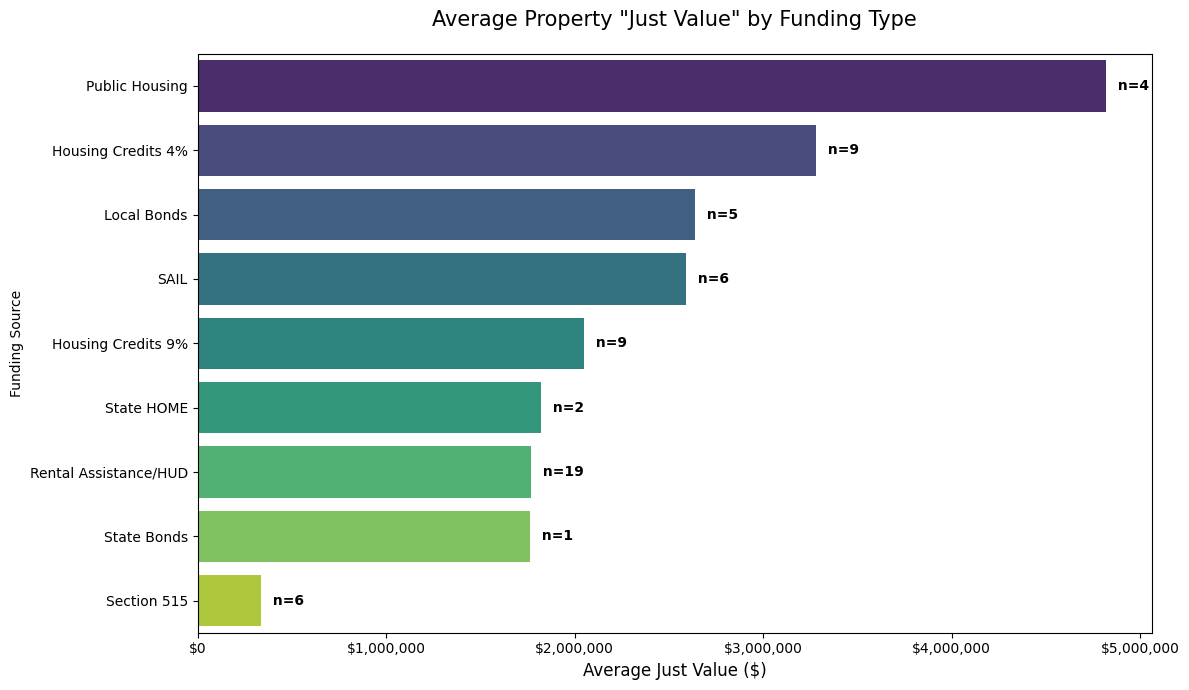

In [150]:
# Define the funding columns
funding_cols = [
    'Has Housing Credits 4%', 'Has Housing Credits 9%', 'Has SAIL',
    'Has State Bonds', 'Has State HOME', 'Has Rental Assistance/HUD',
    'Has Section 515', 'Has Local Bonds', 'Has Public Housing'
]

# Ensure Just Value is numeric (important!)
df_inventory['Just Value ($)'] = pd.to_numeric(df_inventory['Just Value ($)'], errors='coerce').fillna(0)
for col in funding_cols:
    df_inventory[col] = pd.to_numeric(df_inventory[col], errors='coerce').fillna(0)

# Filter for rows that actually have a recorded value
df_val = df_inventory[df_inventory['Just Value ($)'] > 0].copy()

# 2. Calculate Stats
stats = []
for col in funding_cols:
    subset = df_val[df_val[col] == 1]
    if len(subset) > 0:
        stats.append({
            'Funding Source': col.replace('Has ', ''),
            'Avg Value': subset['Just Value ($)'].mean(),
            'Sample Size (n)': len(subset)
        })

df_results = pd.DataFrame(stats).sort_values('Avg Value', ascending=False)

# 3. Create the Visualization
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=df_results,
    x='Avg Value',
    y='Funding Source',
    hue='Funding Source',
    palette='viridis',
    legend=False
)

# FIX: Format the X-axis to show full numbers (e.g., $1,000,000) instead of 1e6
ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

# Add the 'n' counts at the end of the bars
for i, p in enumerate(ax.patches):
    n_val = df_results.iloc[i]['Sample Size (n)']
    ax.annotate(f' n={int(n_val)}', (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0),
                textcoords='offset points')

plt.title('Average Property "Just Value" by Funding Type', fontsize=15, pad=20)
plt.xlabel('Average Just Value ($)', fontsize=12)
plt.tight_layout()
plt.show()

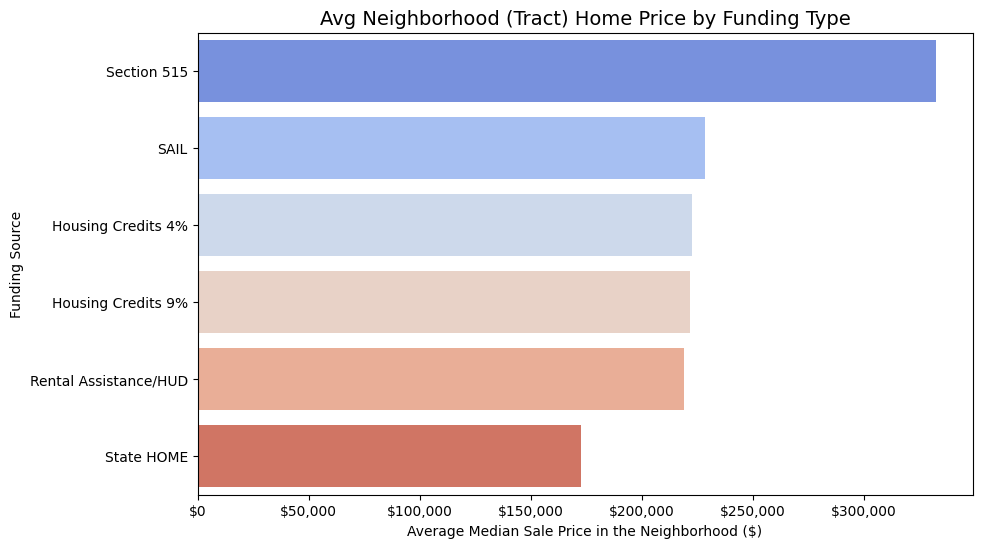

In [151]:
# Define the funding columns and the tract price target
funding_cols = [
    'Has Housing Credits 4%', 'Has Housing Credits 9%', 'Has SAIL',
    'Has State HOME', 'Has Rental Assistance/HUD', 'Has Section 515'
]
target_col = 'Median Single Family Sale Price, 2023, Tract'

# Ensure the columns are numeric
df_inventory[target_col] = pd.to_numeric(df_inventory[target_col], errors='coerce').fillna(0)
for col in funding_cols:
    df_inventory[col] = pd.to_numeric(df_inventory[col], errors='coerce').fillna(0)

# Filter for records with a recorded neighborhood price
df_tract = df_inventory[df_inventory[target_col] > 0].copy()

# 2. Calculate average neighborhood price per program
stats = []
for col in funding_cols:
    subset = df_tract[df_tract[col] == 1]
    if len(subset) > 0:
        stats.append({
            'Funding Source': col.replace('Has ', ''),
            'Avg Neighborhood Price': subset[target_col].mean(),
            'Count': len(subset)
        })

df_results = pd.DataFrame(stats).sort_values('Avg Neighborhood Price', ascending=False)

# 3. Plot the results
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_results, x='Avg Neighborhood Price', y='Funding Source', hue='Funding Source', palette='coolwarm')

# Format the X-axis for currency
ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.title('Avg Neighborhood (Tract) Home Price by Funding Type', fontsize=14)
plt.xlabel('Average Median Sale Price in the Neighborhood ($)')
plt.show()

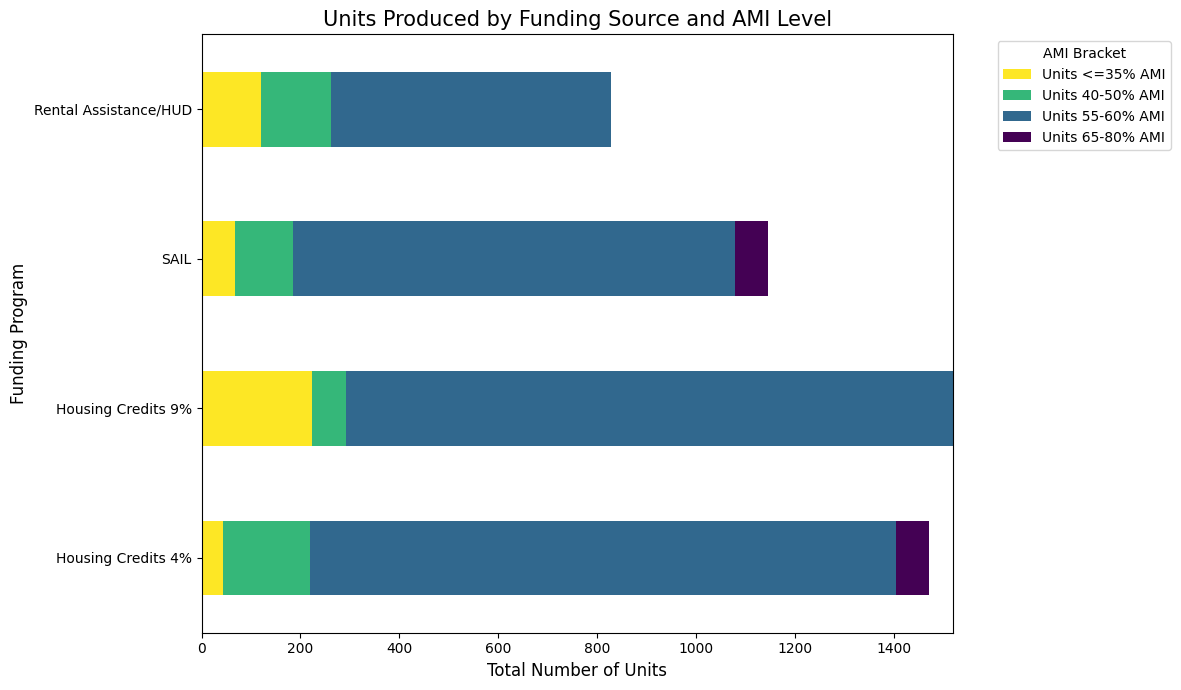

In [152]:
ami_cols = ['Units <=35% AMI', 'Units 40-50% AMI', 'Units 55-60% AMI', 'Units 65-80% AMI']
funding_sources = ['Has Housing Credits 4%', 'Has Housing Credits 9%', 'Has SAIL', 'Has Rental Assistance/HUD']

# Numeric conversion
for col in ami_cols + funding_sources:
    df_inventory[col] = pd.to_numeric(df_inventory[col], errors='coerce').fillna(0)

# 2. Summarize AMI units by funding type
summary_data = []
for f_col in funding_sources:
    subset = df_inventory[df_inventory[f_col] == 1]
    sums = subset[ami_cols].sum()
    sums.name = f_col.replace('Has ', '')
    summary_data.append(sums)

df_ami_plot = pd.concat(summary_data, axis=1).T

# 3. Create a Stacked Bar Chart
df_ami_plot.plot(kind='barh', stacked=True, figsize=(12, 7), colormap='viridis_r')

plt.title('Units Produced by Funding Source and AMI Level', fontsize=15)
plt.xlabel('Total Number of Units', fontsize=12)
plt.ylabel('Funding Program', fontsize=12)
plt.legend(title="AMI Bracket", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

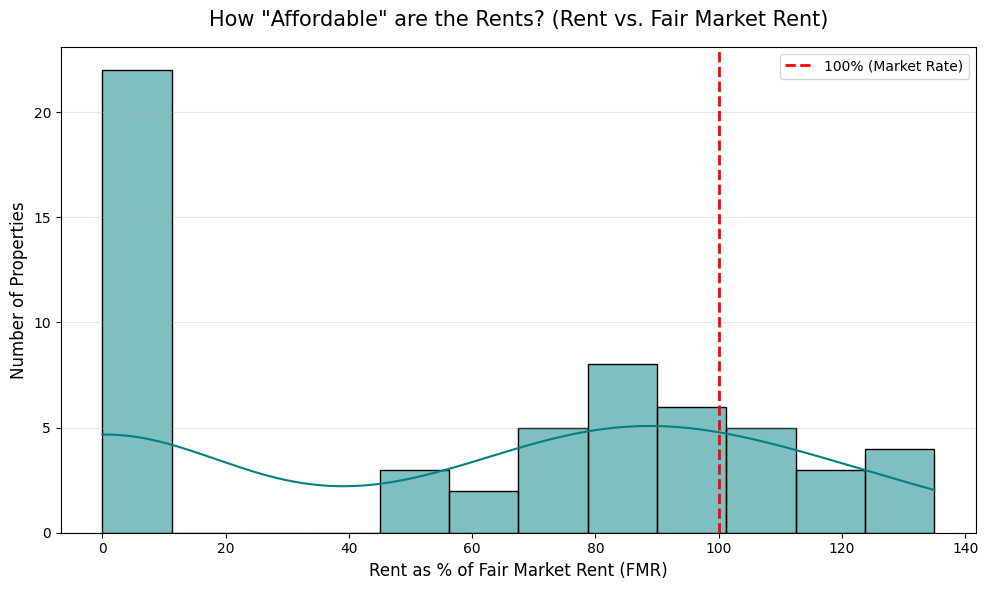

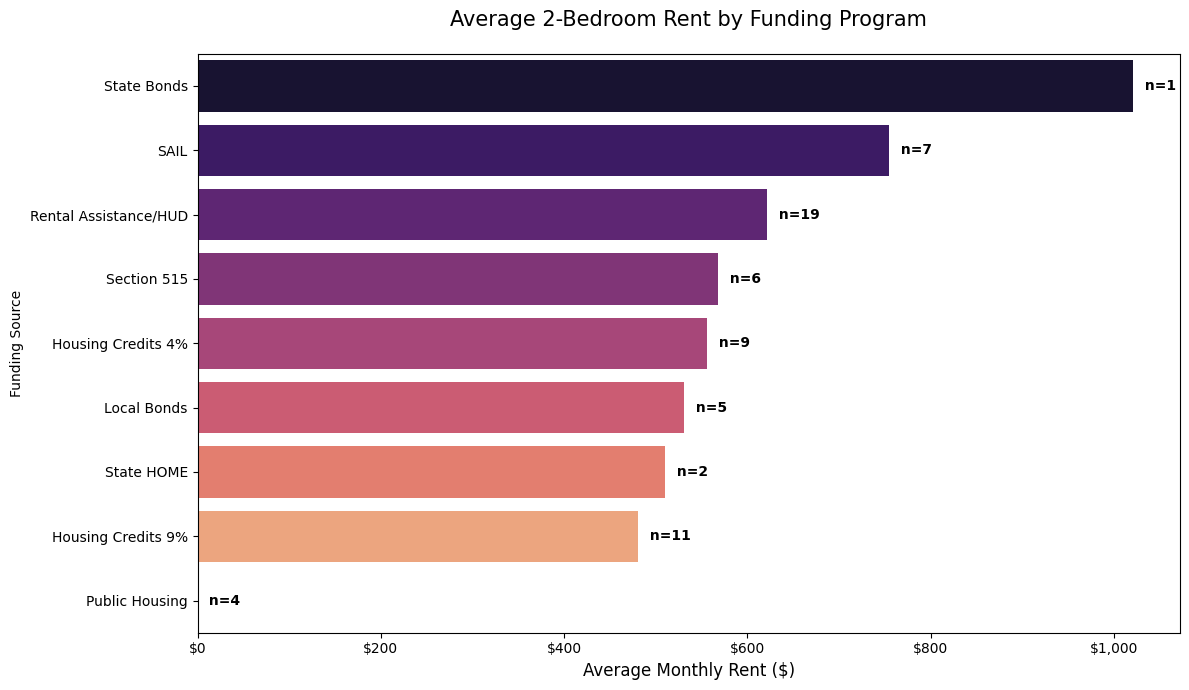

In [153]:
# Clean common placeholders and convert to numeric
df_inventory = df_inventory.replace({'-': 0, 'x': 1, 'not avail.': pd.NA})

# Define the funding columns
funding_cols = [
    'Has Housing Credits 4%', 'Has Housing Credits 9%', 'Has SAIL',
    'Has State Bonds', 'Has State HOME', 'Has Rental Assistance/HUD',
    'Has Section 515', 'Has Local Bonds', 'Has Public Housing'
]

# Columns for analysis
rent_2br_col = '2 BR Av. Rent ($)'
fmr_ratio_col = 'Average Rent/FMR ratio'

# Ensure the data is numeric
df_inventory[rent_2br_col] = pd.to_numeric(df_inventory[rent_2br_col], errors='coerce')
df_inventory[fmr_ratio_col] = pd.to_numeric(df_inventory[fmr_ratio_col], errors='coerce')

for col in funding_cols:
    df_inventory[col] = pd.to_numeric(df_inventory[col], errors='coerce').fillna(0)

# --- ANALYSIS 1: Fair Market Rent (FMR) Distribution ---
plt.figure(figsize=(10, 6))
sns.histplot(df_inventory[fmr_ratio_col].dropna(), bins=12, kde=True, color='teal')
plt.axvline(100, color='red', linestyle='--', linewidth=2, label='100% (Market Rate)')
plt.title('How "Affordable" are the Rents? (Rent vs. Fair Market Rent)', fontsize=15, pad=15)
plt.xlabel('Rent as % of Fair Market Rent (FMR)', fontsize=12)
plt.ylabel('Number of Properties', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- ANALYSIS 4: Average Rent by Funding Source (WITH FIX) ---
rent_stats = []
for col in funding_cols:
    subset = df_inventory[df_inventory[col] == 1]
    valid_rents = subset[rent_2br_col].dropna()

    if len(valid_rents) > 0:
        rent_stats.append({
            'Funding Source': col.replace('Has ', ''),
            'Avg 2BR Rent': valid_rents.mean(),
            'Sample Size (n)': len(valid_rents)
        })

df_rent_analysis = pd.DataFrame(rent_stats).sort_values('Avg 2BR Rent', ascending=False)

plt.figure(figsize=(12, 7))
# FIX APPLIED HERE: Added hue and legend=False
ax = sns.barplot(
    data=df_rent_analysis,
    x='Avg 2BR Rent',
    y='Funding Source',
    hue='Funding Source',
    palette='magma',
    legend=False
)

# Format X-axis for currency
ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

# Add "n" counts to the bars
for i, p in enumerate(ax.patches):
    n_val = df_rent_analysis.iloc[i]['Sample Size (n)']
    ax.annotate(f' n={int(n_val)}',
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', fontsize=10, fontweight='bold',
                xytext=(5, 0), textcoords='offset points')

plt.title('Average 2-Bedroom Rent by Funding Program', fontsize=15, pad=20)
plt.xlabel('Average Monthly Rent ($)', fontsize=12)
plt.tight_layout()
plt.show()


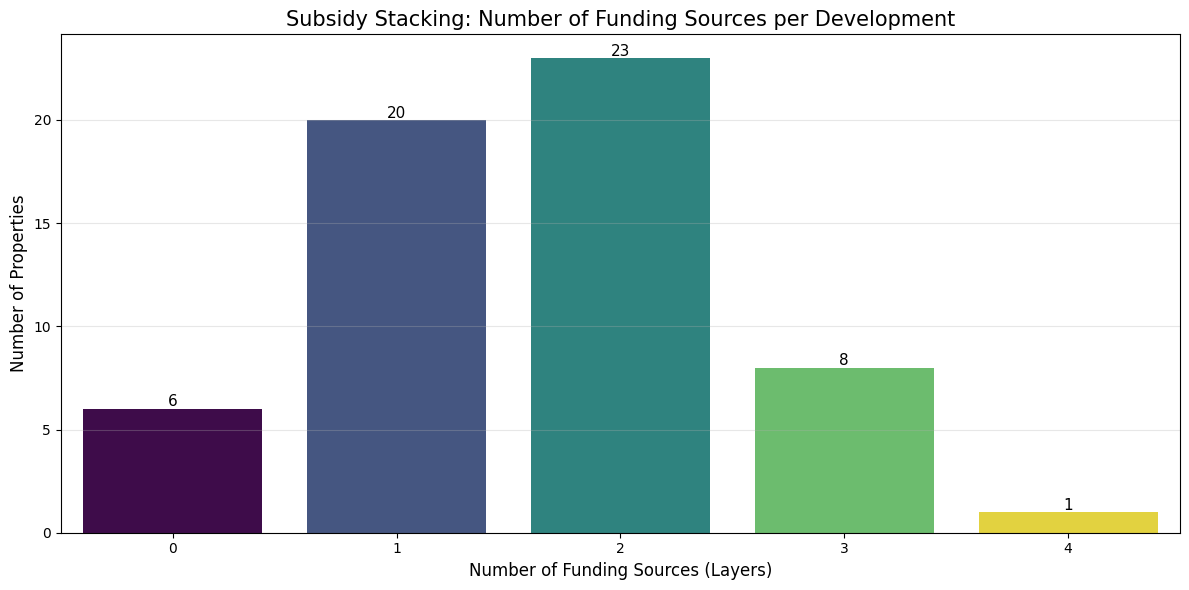

--- Top 10 Most Complex Projects (Highest Subsidy Stacking) ---
             Development Name  Subsidy_Count
10    Pine Meadows Apartments              4
13            Santa Fe Oaks I              3
25      Eden Park at Ironwood              3
14           Santa Fe Oaks II              3
22  Banyan Hammock Apartments              3
31          Hawthorne Heights              3
47          Sweetwater Square              3
53           Woodland Park II              3
41            Pine Grove Apts              3
7                 Harbor Cove              2

Across the entire portfolio, the average development requires 1.62 funding sources.


In [154]:
# 1. CLEANING & SETUP
# We'll use the funding columns identified in your dataset
funding_cols = [
    'Has Housing Credits 4%', 'Has Housing Credits 9%', 'Has SAIL',
    'Has State Bonds', 'Has State HOME', 'Has EHCL', 'Has Demonstration',
    'Has PLP', 'Has Rental Assistance/HUD', 'Has Section 202 Capital Advance',
    'Has Section 202 Direct Loan', 'Has Section 811', 'Has HUD Use Agreement',
    'Has Section 542', 'Has Section 207', 'Has Section 231',
    'Has Public Housing', 'Has Rental Assistance/RD',
    'Has Section 515', 'Has Section 514/516', 'Has Local Bonds'
]

# Ensure all funding columns are numeric (0 or 1)
# This handles the 'x' and '-' characters often found in these exports
df_inventory[funding_cols] = df_inventory[funding_cols].replace({'x': 1, '-': 0}).apply(pd.to_numeric, errors='coerce').fillna(0)

# 2. CALCULATE SUBSIDY STACKING (DENSITY)
df_inventory['Subsidy_Count'] = df_inventory[funding_cols].sum(axis=1).astype(int)

# 3. VISUALIZATION
plt.figure(figsize=(12, 6))
# Using hue to avoid the deprecation warning
ax = sns.countplot(
    data=df_inventory,
    x='Subsidy_Count',
    hue='Subsidy_Count',
    palette='viridis',
    legend=False
)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Subsidy Stacking: Number of Funding Sources per Development', fontsize=15)
plt.xlabel('Number of Funding Sources (Layers)', fontsize=12)
plt.ylabel('Number of Properties', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4. PRINT TOP 10 MOST COMPLEX PROJECTS
# Using 'Development Name' which we verified is the correct column index
print("--- Top 10 Most Complex Projects (Highest Subsidy Stacking) ---")
top_10 = df_inventory[['Development Name', 'Subsidy_Count']].sort_values(by='Subsidy_Count', ascending=False).head(10)
print(top_10)

# 5. QUICK SUMMARY STATS
avg_stack = df_inventory['Subsidy_Count'].mean()
print(f"\nAcross the entire portfolio, the average development requires {avg_stack:.2f} funding sources.")